# Bắt đầu

In [1]:
from PIL import Image
from IPython.display import display
image1 = Image.open("dothi1.png"); image2 = Image.open("dothi2.png");  # Đọc tập tin ảnh của đồ thị cần xử lý

FileNotFoundError: [Errno 2] No such file or directory: 'dothi1.png'

## Bài 1.
Cho đồ thị hàm số **G** (**V**, **E**) như bên dưới:

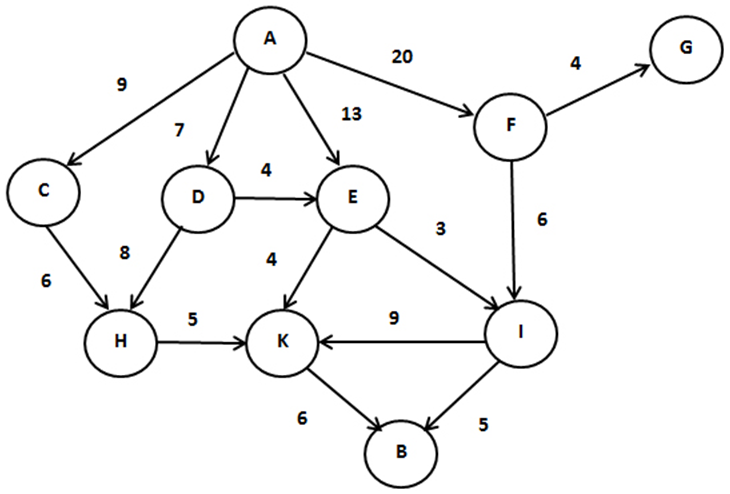

In [ ]:
display(image1)

### 1. Biễu diễn bằng danh sách kề có trọng số

In [ ]:
COST={'A': {'C': 9, 'D': 7, 'E': 13, 'F': 20},
 'B': {},
 'C': {'H': 6},
 'D': {'E': 4, 'H': 8},
 'E': {'I': 3, 'K': 4},
 'F': {'G': 4, 'I': 6},
 'G': {},
 'H': {'K': 5},
 'I': {'B': 5, 'K': 9},
 'K': {'B': 6}}

In [ ]:
import pprint
print(f'{pprint.pformat(COST)}')

NameError: name 'COST' is not defined

In [ ]:
def matrix_adj(G):
    vertices=list(G.keys())
    print("   ",end="")
    for v in vertices:
        print(f"{v:>3}",end="")
    print()
    for u in vertices:
        print(f"{u:>3}",end="")
        for v in vertices:
            w=G[u].get(v,0)
            print(f"{w:>3}",end="")
        print()

In [ ]:
matrix_adj(COST)

     A  B  C  D  E  F  G  H  I  K
  A  0  0  9  7 13 20  0  0  0  0
  B  0  0  0  0  0  0  0  0  0  0
  C  0  0  0  0  0  0  0  6  0  0
  D  0  0  0  0  4  0  0  8  0  0
  E  0  0  0  0  0  0  0  0  3  4
  F  0  0  0  0  0  0  4  0  6  0
  G  0  0  0  0  0  0  0  0  0  0
  H  0  0  0  0  0  0  0  0  0  5
  I  0  5  0  0  0  0  0  0  0  9
  K  0  6  0  0  0  0  0  0  0  0


### 2. Thuật toán Best-First Search

In [ ]:
import heapq # Thư viện Python hỗ trợ push, pop, pushpop để xây dựng heap trên 1 mảng
# Xây dựng MinHeap
class MinHeap(object):
    def __init__(self):                         # Khởi tạo MinHeap rỗng
        self.items = []
        pass
    
    def empty(self):                            # Kiểm tra heap rỗng
        return len(self.items)==0
  
    def push(self, item):                       # Đưa một item vào MinHeap
        heapq.heappush(self.items, item)
        pass
  
    def pop(self):                              # Lấy 1 item có giá trị nhỏ nhất ra khỏi MinHeap
        item = heapq.heappop(self.items)
        return item
    
    def check(self, item):                      # Kiểm tra item có nằm trong MinHeap
        return item in self.items
    
    def update(self, item, new_item):           # Cập nhật lại new_item từ item cho trước
        for i in range(len(self.items)):
            if self.items[i] == item:
                self.items[i] = new_item
                heapq.heapify(self.items)
        pass
  
    pass # MinHeap

In [ ]:
def BestFirstSearch(G, start, goal):
    """
    Tìm đường đi ngắn nhất từ đỉnh start đến goal trong đồ thị G
    Input:
    + Đồ thị G biểu diễn dưới dạng danh sách kề trọng số
    + Đỉnh xuất phát start và tìm kiểm goal
    Return: (path, g) 
    + path[q]: mảng chứa các đỉnh phía trước để đi tới q
    + g[q]: mảng chứa đường đi ngắn nhất từ start đến q
    + (None, None) --> đỉnh start, goal không hợp lệ
    Lưu ý: 
    + Do OPEN là MinHeap nên ta tổ chức dạng (trọng số, đỉnh) để sắp xếp tăng dần trọng số, cũng như lấy được đỉnh
      * Khi đó, thao tác lấy 1 đỉnh với trọng số nhỏ nhất là (trọng số, đỉnh) = OPEN.pop()
      * Ngược lại kiểm tra 1 đỉnh có nằm trong OPEN thì có 2 cách:
        (1) Cách trực tiếp: dùng hàm check với (g(đỉnh), đỉnh) để kiểm tra
        (2) Cách gián tiếp: g.get(đỉnh) is not None ==> đã thấy (trong OPEN hay CLOSED) và đỉnh not in CLOSED
    """
    result = (None, None)
    
    if G.get(start) is None or G.get(goal) is None:
        result = (None, None)
    else:
        path     = {}     # path(q) = p nghĩa là đỉnh p là đỉnh trước của q, nếu là None nghĩa là ko có đỉnh trước
        g        = {}     # g(q) = d nghĩa là khoảng cách ngắn nhất từ start --> q là d
        OPEN     = MinHeap()
        CLOSED   = []
        
        OPEN.push((0, start))               # đưa đỉnh start vào OPEN (0 là chi phí của start)
        path[start] = None                  # trước start không có đỉnh nào
        g[start]    = 0                     # chi phí là 0
        while OPEN.empty() == False:
            cost,u = OPEN.pop()
            if u in CLOSED:
                continue
            CLOSED.append(u)
            if u == goal:
                break
            for v,w in G[u].items():
                new_cost=g[u]+w
                if v not in g or new_cost<g[v]:
                    g[v]=new_cost
                    path[v]=u
                    OPEN.push((new_cost,v))
            
            pass # while
        result = (path, g)
        pass # if 
    return result
    pass # BestFirstSearch

In [ ]:
path, g = BestFirstSearch(COST, 'A', 'B')
print(f'Mảng tối ưu:\n{pprint.pformat(g)}\n')
print(f'Mảng truy hồi đường:\n{pprint.pformat(path)}\n')

Mảng tối ưu:
{'A': 0, 'B': 19, 'C': 9, 'D': 7, 'E': 11, 'F': 20, 'H': 15, 'I': 14, 'K': 15}

Mảng truy hồi đường:
{'A': None,
 'B': 'I',
 'C': 'A',
 'D': 'A',
 'E': 'D',
 'F': 'A',
 'H': 'D',
 'I': 'E',
 'K': 'E'}



In [ ]:
def find_path(path,start,goal):
    result = []
    
    if goal not in path:
        return result
    current=goal
    while current is not None:
        result.append(current)
        current=path.get(current,None)
    result.reverse()
    if result[0] is not start:
        return []
    
    return result
    pass

In [ ]:
find_path(path,'A','B')

['A', 'D', 'E', 'I', 'B']

### 3. vẽ cây tìm kiếm

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def build_search_tree(path):
    tree = nx.DiGraph()
    for child, parent in path.items():
        if parent is not None:
            tree.add_edge(parent, child)
    return tree

def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    Tạo layout dạng cây cho NetworkX
    """
    def _hierarchy_pos(G, root, left, right, vert_loc, xcenter, pos=None, parent=None):
        if pos is None:
            pos = {root:(xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
        children = list(G.successors(root))
        if len(children)!=0:
            dx = (right-left)/len(children)
            nextx = left+dx/2
            for child in children:
                pos = _hierarchy_pos(G, child, nextx-dx/2, nextx+dx/2,
                                     vert_loc-vert_gap, nextx, pos, root)
                nextx += dx
        return pos
    return _hierarchy_pos(G, root, 0, width, vert_loc, xcenter)

def draw_search_tree(tree, root):
    pos = hierarchy_pos(tree, root)
    plt.figure(figsize=(8,6))
    nx.draw(tree, pos, with_labels=True, node_size=1500,
            node_color="lightblue", arrows=True)
    plt.title(f"Cây tìm kiếm từ {root}")
    plt.show()

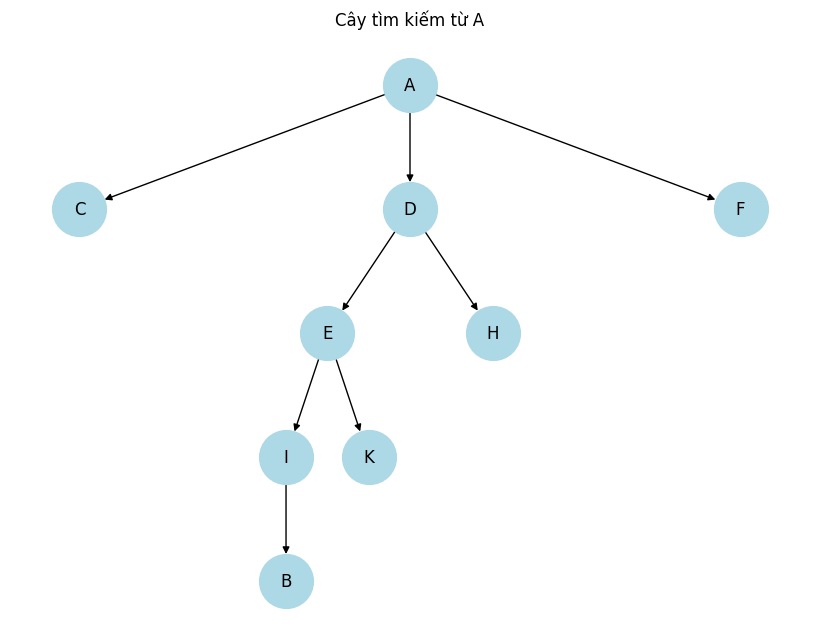

In [ ]:
tree = build_search_tree(path)
draw_search_tree(tree, 'A')

## Bài 2.
Cho đồ thị hàm số **G** (**V**, **E**) cùng tri thức cho trước như bên dưới:

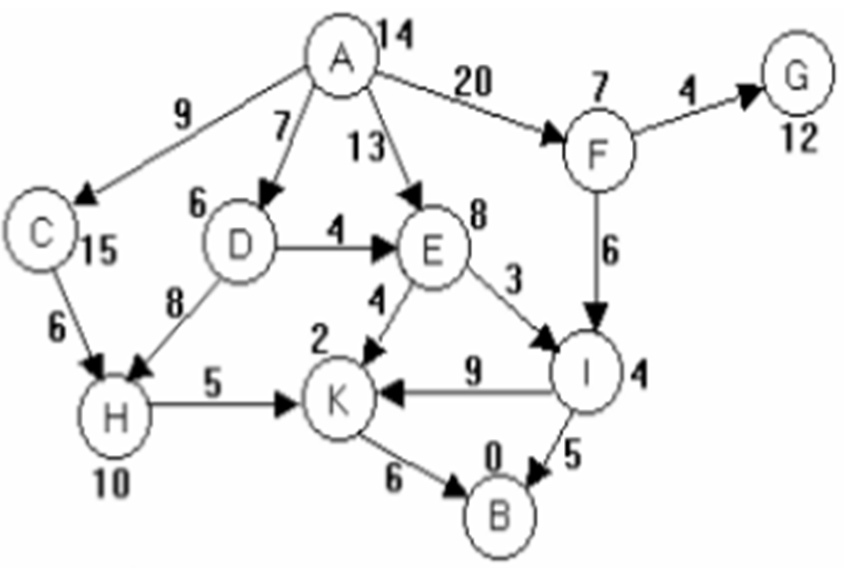

In [ ]:
display(image2)

In [ ]:
h={'A': 14,
 'B': 0,
 'C': 15,
 'D': 6,
 'E': 8,
 'F': 7,
 'G': 12,
 'H': 10,
 'I': 4,
 'K': 2}


In [ ]:
print(f'{pprint.pformat(h)}')

{'A': 14,
 'B': 0,
 'C': 15,
 'D': 6,
 'E': 8,
 'F': 7,
 'G': 12,
 'H': 10,
 'I': 4,
 'K': 2}


### 1. A*

In [ ]:
def AStartSearch(G, start, goal, h = {}):
    """
    Tìm đường đi ngắn nhất từ đỉnh start đến goal trong đồ thị G với tri thức h(p)
    Input:
    + Đồ thị G biểu diễn dưới dạng danh sách kề trọng số
    + Đỉnh xuất phát start và tìm kiểm goal
    + Tri thức h(p) nghĩa là ước lượng chi phí đi từ đỉnh p --> goal
    Return: (path, g) 
    + path[q]: mảng chứa các đỉnh phía trước để đi tới q
    + g[q]: mảng chứa đường đi ngắn nhất từ start đến q
    + (None, None) --> đỉnh start, goal không hợp lệ
    Lưu ý: 
    + Do OPEN là MinHeap nên ta tổ chức dạng (trọng số, đỉnh) để sắp xếp tăng dần trọng số, cũng như lấy được đỉnh
      * Khi đó, thao tác lấy 1 đỉnh với trọng số nhỏ nhất là (trọng số, đỉnh) = OPEN.pop()
      * Ngược lại kiểm tra 1 đỉnh có nằm trong OPEN thì có 2 cách:
        (1) Cách trực tiếp: dùng hàm check với (g(đỉnh), đỉnh) để kiểm tra
        (2) Cách gián tiếp: g.get(đỉnh) is not None ==> đã thấy (trong OPEN hay CLOSED) và đỉnh not in CLOSED
    """
    result = (None, None)
    
    if G.get(start) is None or G.get(goal) is None:
        result = (None, None)
    else:
        path     = {}     # path(q) = p nghĩa là đỉnh p là đỉnh trước của q, nếu là None nghĩa là ko có đỉnh trước
        g        = {}     # g(q) = d nghĩa là khoảng cách ngắn nhất từ start --> q là d
        f        = {}     # f(p) = g(p) + h(p), h(p) = None ==> h(p) = 0 (không có tri thức từ p --> goal)
        OPEN     = MinHeap()
        CLOSED   = []
        
        path[start] = None                        # trước start không có đỉnh nào
        g[start]    = 0                           # chi phí là 0
        f[start]    = g[start] + h.get(start, 0)  # nếu 1 đỉnh ko có trong h --> tri thức chưa có --> h = 0
        OPEN.push((f[start], start))              # đưa đỉnh start vào OPEN với chi phí f(start)
        while OPEN.empty() == False:
            (_, p) = OPEN.pop() # lấy đỉnh p ra khỏi OPEN với f(p) min
            if p in CLOSED:
                continue                   
            CLOSED.append(p)                      # đưa p vào CLOSED
            if p==goal:
                break
            for v,w in G[p].items():
                g_new=g[p]+w
                if v not in g or g_new<g[v]:
                    g[v]=g_new
                    path[v]=p
                    f[v]=g[v]+h.get(v,0)
                    OPEN.push((f[v],v))
            # ...
            
            pass # while
        result = (path, g)
        pass # if 
    return result
    pass # AStartSearch

In [ ]:
path, g = AStartSearch(COST, 'A', 'B')
print(f'Mảng tối ưu:\n{pprint.pformat(g)}\n')
print(f'Mảng truy hồi đường:\n{pprint.pformat(path)}\n')

Mảng tối ưu:
{'A': 0, 'B': 19, 'C': 9, 'D': 7, 'E': 11, 'F': 20, 'H': 15, 'I': 14, 'K': 15}

Mảng truy hồi đường:
{'A': None,
 'B': 'I',
 'C': 'A',
 'D': 'A',
 'E': 'D',
 'F': 'A',
 'H': 'D',
 'I': 'E',
 'K': 'E'}



### 2. vẽ cây tìm kiếm

In [ ]:
def find_path_a(path, start, goal):
    """
    Cho mang truy hoi duong, tim ds dinh tu start --> goal
    """
    result = []
    
    if goal not in path:
        return result
    current=goal
    while current is not None:
        result.append(current)
        current=path.get(current,None)
    result.reverse()
    if result[0] is not start:
        return []
    
    return result
    pass

In [ ]:
find_path_a(path, 'A', 'B')

['A', 'D', 'E', 'I', 'B']

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def build_search_tree(path):
    tree = nx.DiGraph()
    for child, parent in path.items():
        if parent is not None:
            tree.add_edge(parent, child)
    return tree

def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    Tạo layout dạng cây cho NetworkX
    """
    def _hierarchy_pos(G, root, left, right, vert_loc, xcenter, pos=None, parent=None):
        if pos is None:
            pos = {root:(xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
        children = list(G.successors(root))
        if len(children)!=0:
            dx = (right-left)/len(children)
            nextx = left+dx/2
            for child in children:
                pos = _hierarchy_pos(G, child, nextx-dx/2, nextx+dx/2,
                                     vert_loc-vert_gap, nextx, pos, root)
                nextx += dx
        return pos
    return _hierarchy_pos(G, root, 0, width, vert_loc, xcenter)

def draw_search_tree(tree, root):
    pos = hierarchy_pos(tree, root)
    plt.figure(figsize=(8,6))
    nx.draw(tree, pos, with_labels=True, node_size=1500,
            node_color="lightblue", arrows=True)
    plt.title(f"Cây tìm kiếm từ {root}")
    plt.show()

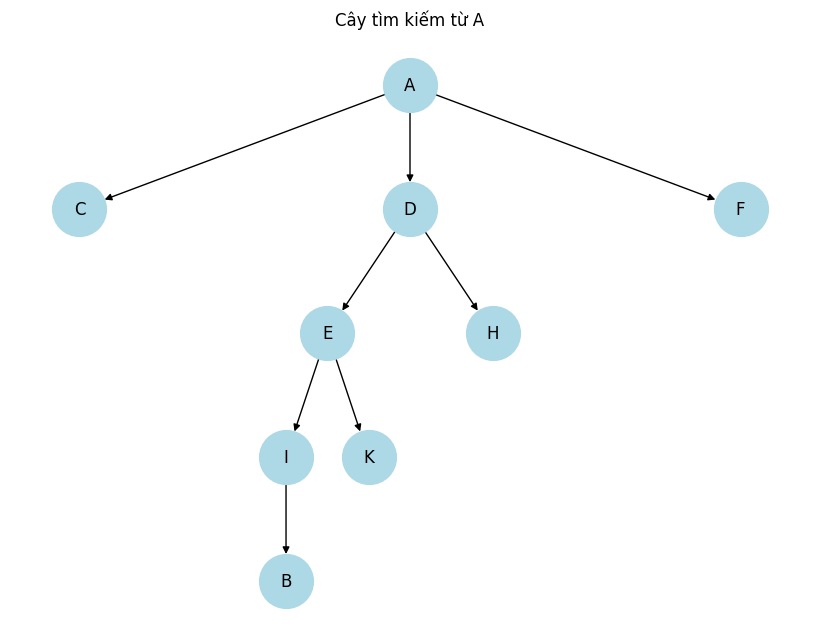

In [ ]:
tree=build_search_tree(path)
draw_search_tree(tree,'A')